<a href="https://colab.research.google.com/github/heoconngoc/Anni/blob/main/19_Hyperparam_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Multi-Fidelity vs Random Search

In [5]:
# Setup

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import random

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
# Load data

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

def get_dataloader(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    return train_loader, test_loader

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 216kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.03MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.0MB/s]


In [7]:
# Model: Light MLP

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
# Train with 1 config
def train_one_config(lr, batch_size, max_epochs):
    model = SimpleMLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_loader, test_loader = get_dataloader(batch_size)

    errors = []

    for epoch in range(max_epochs):
        model.train()

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = model(x)
            loss = loss_fn(y_hat, y)
            loss.backward()
            optimizer.step()

        # validation error
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                y_hat = model(x)
                pred = y_hat.argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)

        error = 1 - correct / total
        errors.append(error)

    return errors

In [9]:
# Sample config

def sample_config():
    return {
        "lr": 10 ** random.uniform(-3, -1),   # log scale
        "batch_size": random.choice([32, 64, 128])
    }

In [10]:
# Random search

def run_random_search(n_configs=6, max_epochs=10):
    results = {}

    for i in range(n_configs):
        config = sample_config()
        errors = train_one_config(config["lr"], config["batch_size"], max_epochs)

        results[i] = {
            "config": config,
            "errors": errors,
            "status": "alive"
        }

    return results

In [11]:
# SUCCESSIVE HALVING

def run_successive_halving(n_configs=8, eta=2, rungs=[2,4,8,10]):
    configs = [sample_config() for _ in range(n_configs)]

    results = {i: {"config": configs[i], "errors": [], "status": "alive"} for i in range(n_configs)}

    active_ids = list(range(n_configs))

    for r in rungs:
        print(f"\n=== RUNG {r} ===")

        rung_errors = []

        for cid in active_ids:
            config = results[cid]["config"]

            errors = train_one_config(config["lr"], config["batch_size"], r)

            results[cid]["errors"] = errors
            final_error = errors[-1]

            rung_errors.append((cid, final_error))

        # sort
        rung_errors.sort(key=lambda x: x[1])

        # keep top 1/eta
        k = max(1, len(rung_errors)//eta)
        survivors = [cid for cid, _ in rung_errors[:k]]

        # mark killed
        for cid in active_ids:
            if cid not in survivors:
                results[cid]["status"] = "killed"

        active_ids = survivors

        print("Survivors:", active_ids)

        if len(active_ids) == 1:
            break

    return results

In [12]:
# RUN EXPERIMENTS

print("Running Random Search...")
random_results = run_random_search()

print("\nRunning Successive Halving...")
sh_results = run_successive_halving()

Running Random Search...

Running Successive Halving...

=== RUNG 2 ===
Survivors: [4, 2, 5, 0]

=== RUNG 4 ===
Survivors: [2, 4]

=== RUNG 8 ===
Survivors: [2]


In [13]:
def plot_learning_curves(results, title):
    plt.figure(figsize=(6,4))

    for cid, data in results.items():
        errors = data["errors"]
        if not errors:
            continue

        if data["status"] == "killed":
            plt.plot(errors, alpha=0.4)
        else:
            plt.plot(errors, linewidth=2)

    plt.xlabel("Epoch")
    plt.ylabel("Validation Error")
    plt.title(title)
    plt.show()

In [14]:
def plot_scatter(results, title):
    plt.figure(figsize=(5,4))

    for cid, data in results.items():
        errors = data["errors"]
        for epoch, err in enumerate(errors):
            plt.scatter(epoch+1, err, alpha=0.6)

    plt.xlabel("Epoch")
    plt.ylabel("Validation Error")
    plt.title(title)
    plt.show()

In [15]:
def plot_survival(results):
    counts = {}

    for cid, data in results.items():
        for epoch in range(len(data["errors"])):
            counts[epoch+1] = counts.get(epoch+1, 0) + 1

    epochs = sorted(counts.keys())
    values = [counts[e] for e in epochs]

    plt.figure(figsize=(5,4))
    plt.plot(epochs, values, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Number of configs alive")
    plt.title("Survival Plot (SH)")
    plt.show()

=== RANDOM SEARCH ===


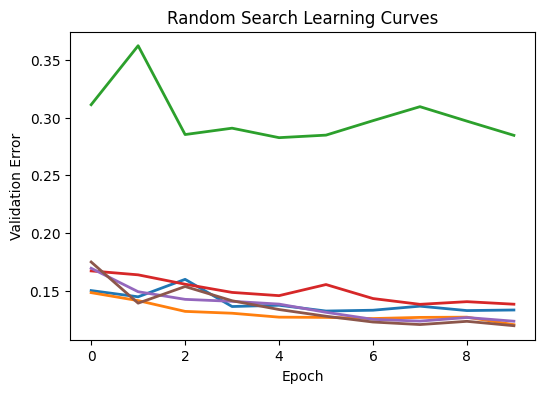

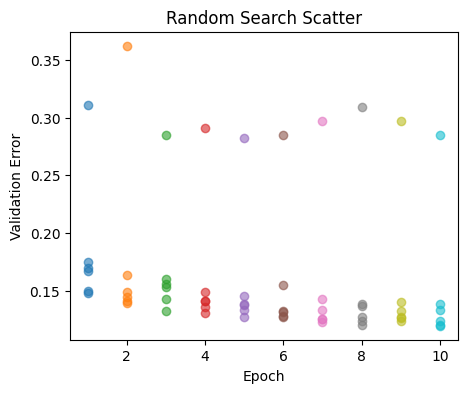


=== SUCCESSIVE HALVING ===


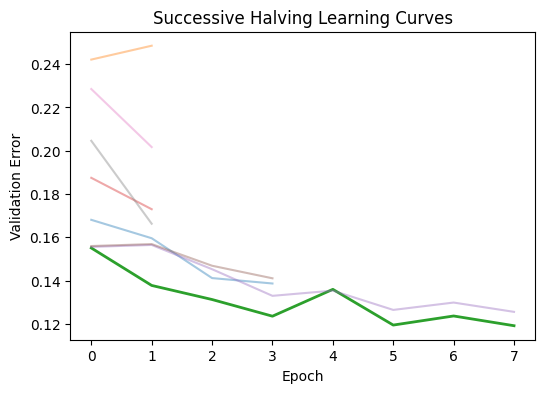

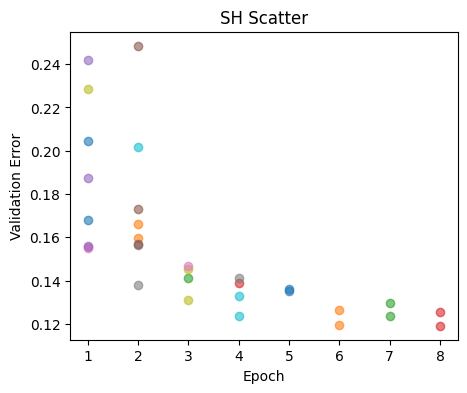

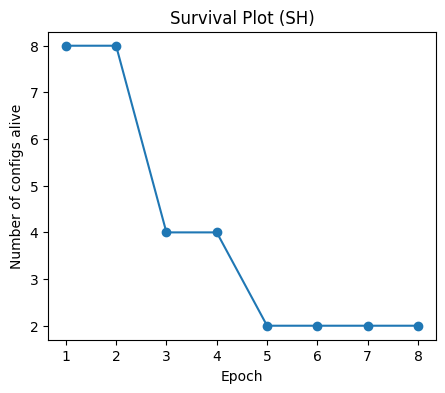

In [16]:
print("=== RANDOM SEARCH ===")
plot_learning_curves(random_results, "Random Search Learning Curves")
plot_scatter(random_results, "Random Search Scatter")

print("\n=== SUCCESSIVE HALVING ===")
plot_learning_curves(sh_results, "Successive Halving Learning Curves")
plot_scatter(sh_results, "SH Scatter")
plot_survival(sh_results)